# SVM Model v03 — Expanded Categories
This notebook extends `svm_model_v02` by expanding the target categories from 4 biological systems to **13 specialties** — all categories with sufficient sample sizes (≥100), from **Surgery** down to **ENT - Otolaryngology**.

### Changes from v02:
- **13 target classes** instead of 4
- Same preprocessing pipeline (from `model.ipynb` EDA)
- Same two-model comparison (Basic vs Combined features)
- ROC curve analysis included

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


Loading preprocessed dataset...
Original dataset shape: (4966, 7)
Filtered dataset shape: (3990, 10)
Number of target classes: 13

--- Filtered Dataset Class Distribution ---
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Name: count, dtype: int64

Total patient notes: 3990


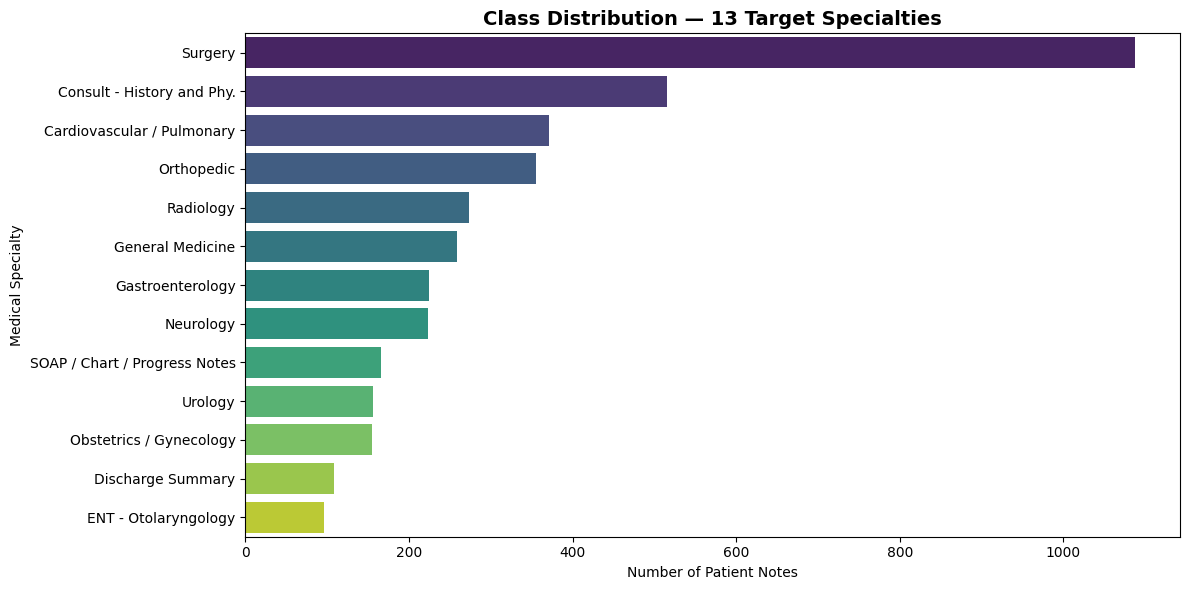

In [2]:
# ============================================================
# Data Loading & Preprocessing (matching model.ipynb EDA logic)
# ============================================================

# 1. Load the dataset
print("Loading preprocessed dataset...")
df = pd.read_csv("processed_clinical_data.csv")
print(f"Original dataset shape: {df.shape}")

# 2. Drop rows missing extracted_features or medical_specialty
df = df.dropna(subset=['extracted_features', 'medical_specialty'])
df['medical_specialty'] = df['medical_specialty'].str.strip()

# 3. Define expanded target classes (Surgery down to ENT - Otolaryngology)
target_classes = [
    'Surgery',
    'Consult - History and Phy.',
    'Cardiovascular / Pulmonary',
    'Orthopedic',
    'Radiology',
    'General Medicine',
    'Gastroenterology',
    'Neurology',
    'SOAP / Chart / Progress Notes',
    'Urology',
    'Obstetrics / Gynecology',
    'Discharge Summary',
    'ENT - Otolaryngology',
]

# 4. Filter the dataframe to only include target classes
df_filtered = df[df['medical_specialty'].isin(target_classes)].copy()

# 5. Clean the feature strings
df_filtered['clean_features'] = df_filtered['extracted_features'].str.replace(r"[\[\]',]", "", regex=True)

# 6. Handle missing values in text columns
text_cols = ['transcription', 'keywords', 'clean_features']
for col in text_cols:
    df_filtered[col] = df_filtered[col].fillna('')

# 7. Create feature columns
# Model 1: transcription only
df_filtered['text_basic'] = df_filtered['transcription']
# Model 2: combined (transcription + keywords + clean_features)
df_filtered['text_combined'] = df_filtered['transcription'] + " " + df_filtered['keywords'] + " " + df_filtered['clean_features']

print(f"Filtered dataset shape: {df_filtered.shape}")
print(f"Number of target classes: {len(target_classes)}")
print("\n--- Filtered Dataset Class Distribution ---")
print(df_filtered['medical_specialty'].value_counts())
print(f"\nTotal patient notes: {len(df_filtered)}")

# 8. Visualize class distribution
plt.figure(figsize=(12, 6))
class_counts = df_filtered['medical_specialty'].value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis', hue=class_counts.index, legend=False)
plt.title('Class Distribution — 13 Target Specialties', fontsize=14, fontweight='bold')
plt.xlabel('Number of Patient Notes')
plt.ylabel('Medical Specialty')
plt.tight_layout()
plt.show()

In [3]:
# Define features and target
X_basic = df_filtered['text_basic']
X_combined = df_filtered['text_combined']
y = df_filtered['medical_specialty']

# Split for Model 1 (80% train, 20% test)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_basic, y, test_size=0.2, random_state=42, stratify=y
)

# Split for Model 2 (Using exactly the same indices)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train_b.shape[0]}")
print(f"Testing samples: {X_test_b.shape[0]}")

Training samples: 3192
Testing samples: 798


In [4]:
# --- MODEL 1: Basic Features (transcription only) ---

pipeline_b = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=10000, sublinear_tf=True)),
    ('svm', SVC(random_state=42))
])

# Define parameter grid for Grid Search
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

# GridSearchCV with 5-fold cross validation on the training data
grid_b = GridSearchCV(pipeline_b, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

print("Training Model 1 (Basic Text) with GridSearchCV...")
grid_b.fit(X_train_b, y_train_b)

print(f"\nBest Parameters for Model 1: {grid_b.best_params_}")
print(f"Best CV Accuracy (Model 1): {grid_b.best_score_:.4f}")

Training Model 1 (Basic Text) with GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits



Best Parameters for Model 1: {'svm__C': 0.1, 'svm__kernel': 'linear'}
Best CV Accuracy (Model 1): 0.4279


Classification Report - Model 1 (Basic Text):

                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.46      0.18      0.25        74
   Consult - History and Phy.       0.36      0.94      0.52       103
            Discharge Summary       0.00      0.00      0.00        21
         ENT - Otolaryngology       0.00      0.00      0.00        19
             Gastroenterology       0.00      0.00      0.00        45
             General Medicine       0.00      0.00      0.00        52
                    Neurology       0.00      0.00      0.00        45
      Obstetrics / Gynecology       0.00      0.00      0.00        31
                   Orthopedic       0.25      0.01      0.03        71
                    Radiology       0.37      0.58      0.45        55
SOAP / Chart / Progress Notes       0.00      0.00      0.00        33
                      Surgery       0.52      0.99      0.68       218
                      Urology

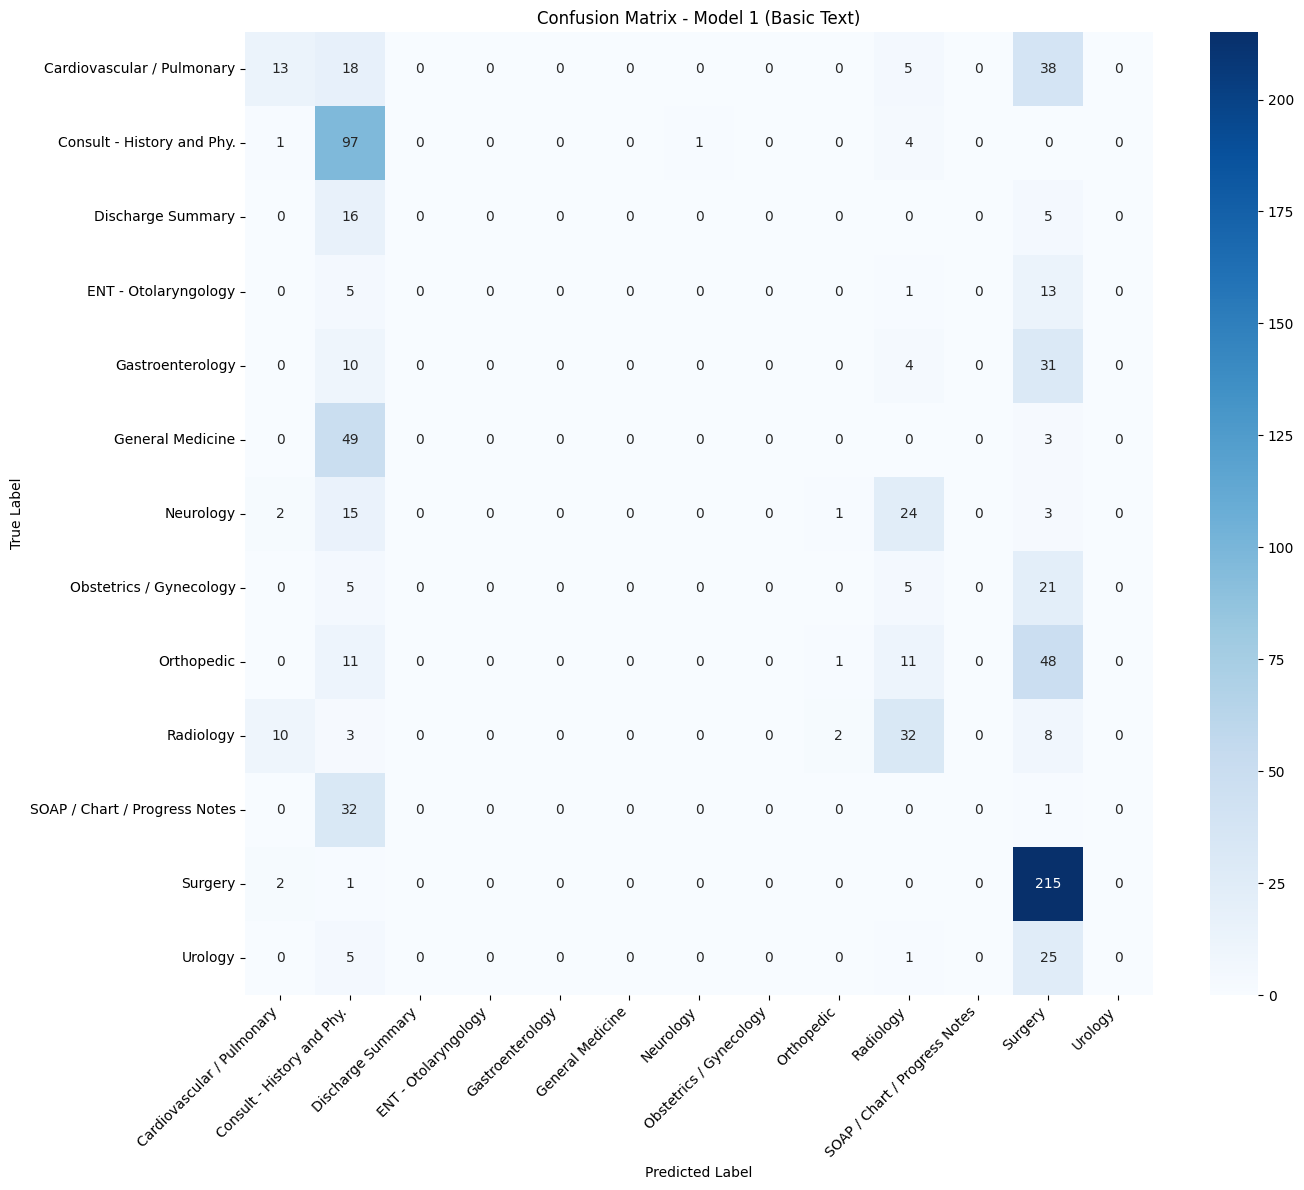

In [5]:
# Evaluate Model 1 on the hold-out test set
y_pred_b = grid_b.predict(X_test_b)

print("Classification Report - Model 1 (Basic Text):\n")
print(classification_report(y_test_b, y_pred_b, zero_division=0))

# Confusion Matrix for Model 1
plt.figure(figsize=(14, 12))
cm_b = confusion_matrix(y_test_b, y_pred_b)
sns.heatmap(cm_b, annot=True, cmap="Blues", fmt='d',
            xticklabels=grid_b.best_estimator_.classes_,
            yticklabels=grid_b.best_estimator_.classes_)
plt.title("Confusion Matrix - Model 1 (Basic Text)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# --- MODEL 2: Combined Features (transcription + keywords + clean_features) ---

pipeline_c = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=10000, sublinear_tf=True)),
    ('svm', SVC(random_state=42))
])

grid_c = GridSearchCV(pipeline_c, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

print("Training Model 2 (Combined Text) with GridSearchCV...")
grid_c.fit(X_train_c, y_train_c)

print(f"\nBest Parameters for Model 2: {grid_c.best_params_}")
print(f"Best CV Accuracy (Model 2): {grid_c.best_score_:.4f}")

Training Model 2 (Combined Text) with GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best Parameters for Model 2: {'svm__C': 10, 'svm__kernel': 'linear'}
Best CV Accuracy (Model 2): 0.6438


Classification Report - Model 2 (Combined Text):

                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.77      0.76      0.76        74
   Consult - History and Phy.       0.53      0.55      0.54       103
            Discharge Summary       0.68      0.81      0.74        21
         ENT - Otolaryngology       0.88      0.79      0.83        19
             Gastroenterology       0.82      0.71      0.76        45
             General Medicine       0.47      0.52      0.49        52
                    Neurology       0.55      0.58      0.57        45
      Obstetrics / Gynecology       0.86      0.77      0.81        31
                   Orthopedic       0.57      0.66      0.61        71
                    Radiology       0.70      0.87      0.77        55
SOAP / Chart / Progress Notes       1.00      0.79      0.88        33
                      Surgery       0.87      0.79      0.83       218
                      Urol

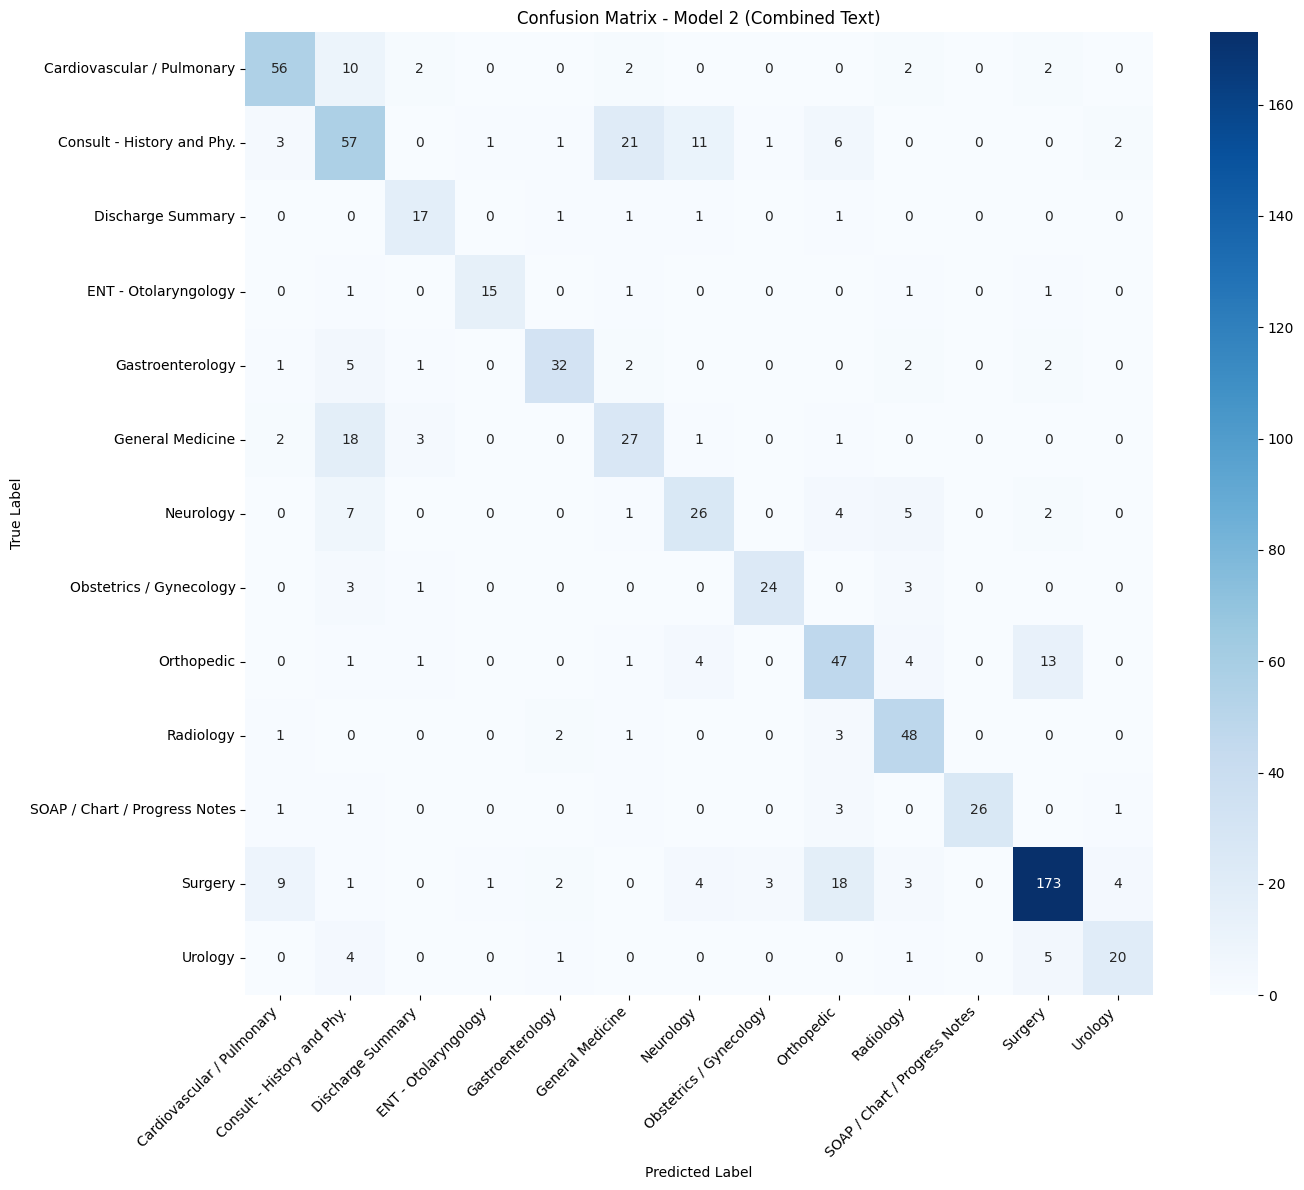

In [7]:
# Evaluate Model 2 on the hold-out test set
y_pred_c = grid_c.predict(X_test_c)

print("Classification Report - Model 2 (Combined Text):\n")
print(classification_report(y_test_c, y_pred_c, zero_division=0))

# Confusion Matrix for Model 2
plt.figure(figsize=(14, 12))
cm_c = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm_c, annot=True, cmap="Blues", fmt='d',
            xticklabels=grid_c.best_estimator_.classes_,
            yticklabels=grid_c.best_estimator_.classes_)
plt.title("Confusion Matrix - Model 2 (Combined Text)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## ROC Curve Analysis

Using the **One-vs-Rest (OvR)** approach to compute per-class ROC curves and AUC scores for each of the 13 specialties.

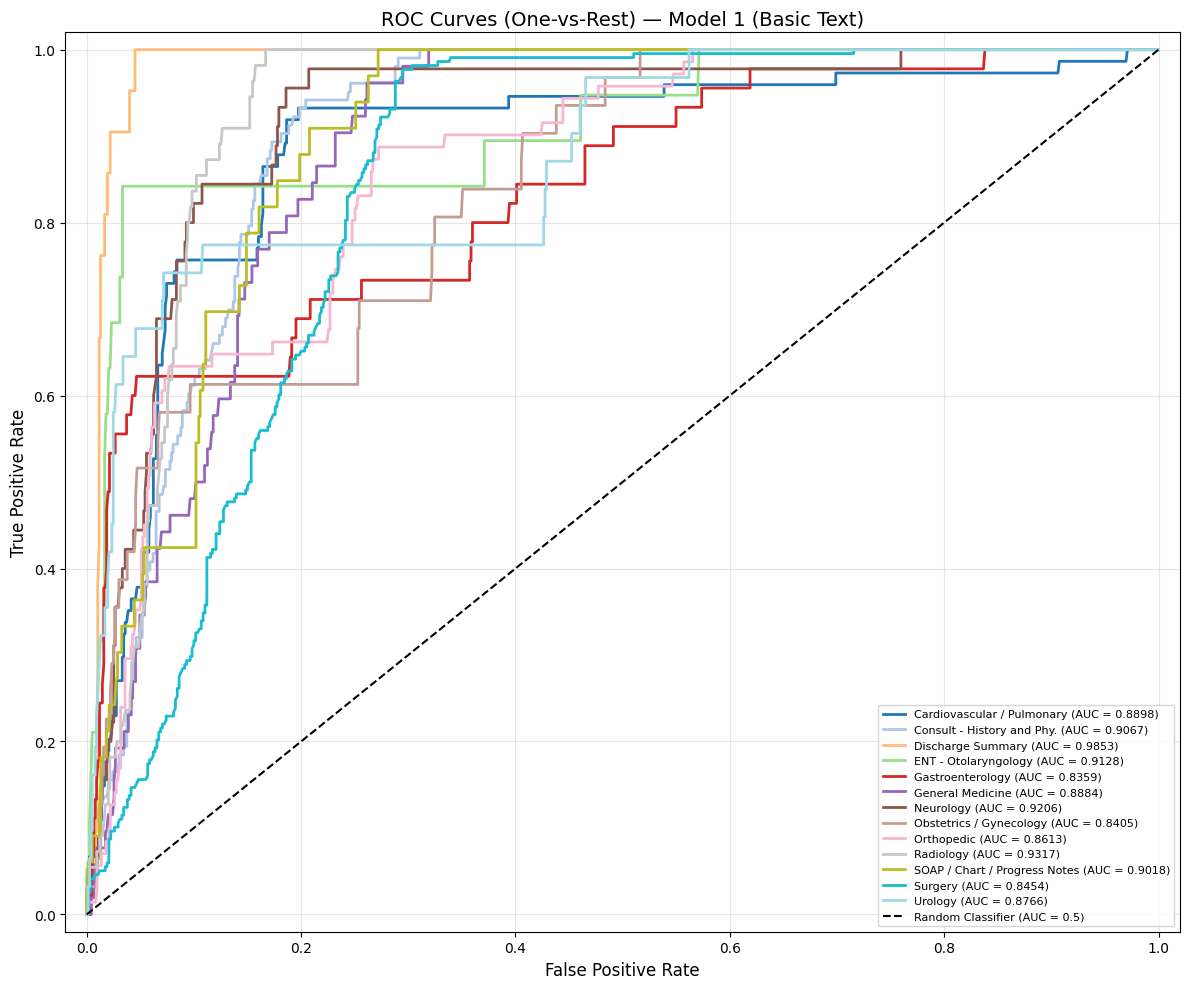


--- AUC Summary for Model 1 (Basic Text) ---
  Cardiovascular / Pulmonary: AUC = 0.8898
  Consult - History and Phy.: AUC = 0.9067
  Discharge Summary: AUC = 0.9853
  ENT - Otolaryngology: AUC = 0.9128
  Gastroenterology: AUC = 0.8359
  General Medicine: AUC = 0.8884
  Neurology: AUC = 0.9206
  Obstetrics / Gynecology: AUC = 0.8405
  Orthopedic: AUC = 0.8613
  Radiology: AUC = 0.9317
  SOAP / Chart / Progress Notes: AUC = 0.9018
  Surgery: AUC = 0.8454
  Urology: AUC = 0.8766
  Macro-Average AUC: 0.8921


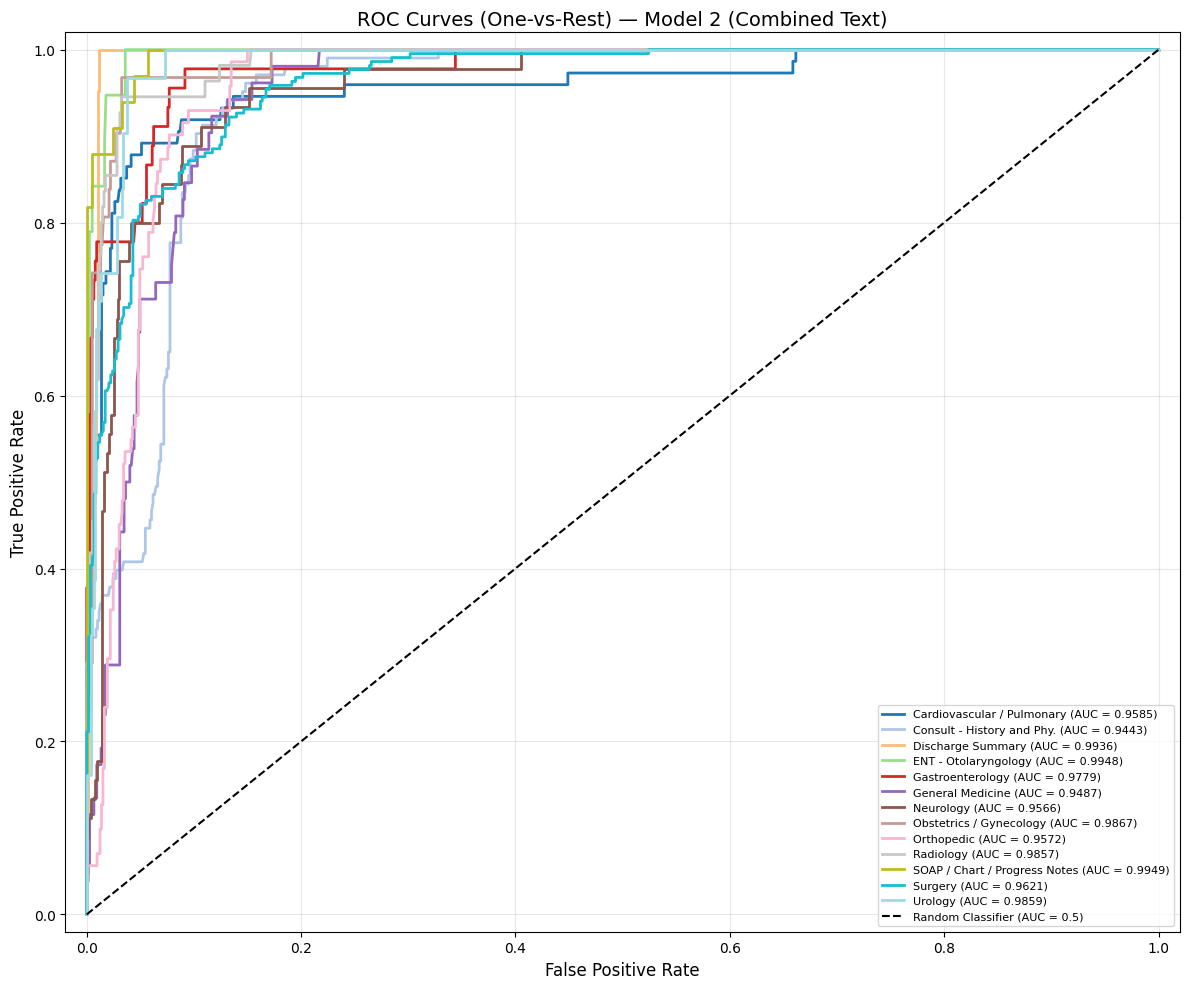


--- AUC Summary for Model 2 (Combined Text) ---
  Cardiovascular / Pulmonary: AUC = 0.9585
  Consult - History and Phy.: AUC = 0.9443
  Discharge Summary: AUC = 0.9936
  ENT - Otolaryngology: AUC = 0.9948
  Gastroenterology: AUC = 0.9779
  General Medicine: AUC = 0.9487
  Neurology: AUC = 0.9566
  Obstetrics / Gynecology: AUC = 0.9867
  Orthopedic: AUC = 0.9572
  Radiology: AUC = 0.9857
  SOAP / Chart / Progress Notes: AUC = 0.9949
  Surgery: AUC = 0.9621
  Urology: AUC = 0.9859
  Macro-Average AUC: 0.9728


In [8]:
# --- Helper function to plot multi-class ROC curves ---
def plot_multiclass_roc(grid_model, X_test, y_test, model_name):
    """
    Plot One-vs-Rest ROC curves for a multi-class SVM classifier.
    Uses decision_function scores as the ranking metric.
    """
    classes = grid_model.best_estimator_.classes_
    n_classes = len(classes)

    # Binarize the true labels: shape (n_samples, n_classes)
    y_test_bin = label_binarize(y_test, classes=classes)

    # Get decision function scores: shape (n_samples, n_classes)
    y_score = grid_model.decision_function(X_test)

    # Compute ROC curve and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot
    plt.figure(figsize=(12, 10))
    cmap = plt.cm.get_cmap('tab20', n_classes)

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=cmap(i), lw=2,
                 label=f'{classes[i]} (AUC = {roc_auc[i]:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves (One-vs-Rest) — {model_name}', fontsize=14)
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f'\n--- AUC Summary for {model_name} ---')
    for i in range(n_classes):
        print(f'  {classes[i]}: AUC = {roc_auc[i]:.4f}')
    macro_auc = np.mean(list(roc_auc.values()))
    print(f'  Macro-Average AUC: {macro_auc:.4f}')


# --- ROC Curve for Model 1 (Basic Text) ---
plot_multiclass_roc(grid_b, X_test_b, y_test_b, 'Model 1 (Basic Text)')

# --- ROC Curve for Model 2 (Combined Text) ---
plot_multiclass_roc(grid_c, X_test_c, y_test_c, 'Model 2 (Combined Text)')

In [9]:
# Save models to disk
joblib.dump(grid_b.best_estimator_, 'svm_model_v03_basic.pkl')
joblib.dump(grid_c.best_estimator_, 'svm_model_v03_combined.pkl')
print("Models saved successfully to disk (svm_model_v03_basic.pkl, svm_model_v03_combined.pkl).")

Models saved successfully to disk (svm_model_v03_basic.pkl, svm_model_v03_combined.pkl).


## Additional Models: PCA and RFE Comparison
We will now compare the base models with dimensionality reduction techniques (PCA via TruncatedSVD and Backward Elimination via RFE).


### 1. Model 1: Basic Features + PCA (TruncatedSVD)


In [10]:
# --- MODEL 1 + PCA ---
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report

# We use best parameters typically found (C=1.0, kernel='linear') for the baseline SVM
pipeline_b_pca = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=10000, sublinear_tf=True)),
    ('pca', TruncatedSVD(n_components=300, random_state=42)),
    ('svm', SVC(C=1.0, kernel='linear', random_state=42))
])

print("Training Model 1 (Basic Text) + PCA...")
pipeline_b_pca.fit(X_train_b, y_train_b)
y_pred_b_pca = pipeline_b_pca.predict(X_test_b)

print("\nClassification Report - Model 1 + PCA:")
print(classification_report(y_test_b, y_pred_b_pca, zero_division=0))


Training Model 1 (Basic Text) + PCA...

Classification Report - Model 1 + PCA:
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.48      0.38      0.42        74
   Consult - History and Phy.       0.45      0.86      0.59       103
            Discharge Summary       0.63      0.81      0.71        21
         ENT - Otolaryngology       0.25      0.05      0.09        19
             Gastroenterology       0.00      0.00      0.00        45
             General Medicine       0.50      0.02      0.04        52
                    Neurology       0.47      0.38      0.42        45
      Obstetrics / Gynecology       0.25      0.16      0.20        31
                   Orthopedic       0.44      0.11      0.18        71
                    Radiology       0.42      0.49      0.45        55
SOAP / Chart / Progress Notes       0.57      0.48      0.52        33
                      Surgery       0.55      0.85      0.66       2

### 2. Model 1: Basic Features + RFE (Backward Elimination)
> Note: We reduce the TF-IDF `max_features` to 1000 for RFE to ensure it runs in a reasonable amount of time. Running RFE on 10,000 features is extremely computationally expensive.


In [11]:
# --- MODEL 1 + RFE ---
from sklearn.feature_selection import RFE

pipeline_b_rfe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=1000, sublinear_tf=True)),
    ('rfe', RFE(estimator=LinearSVC(random_state=42), n_features_to_select=100, step=0.1)),
    ('svm', SVC(C=1.0, kernel='linear', random_state=42))
])

print("Training Model 1 (Basic Text) + RFE...")
pipeline_b_rfe.fit(X_train_b, y_train_b)
y_pred_b_rfe = pipeline_b_rfe.predict(X_test_b)

print("\nClassification Report - Model 1 + RFE:")
print(classification_report(y_test_b, y_pred_b_rfe, zero_division=0))


Training Model 1 (Basic Text) + RFE...

Classification Report - Model 1 + RFE:
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.50      0.28      0.36        74
   Consult - History and Phy.       0.39      0.87      0.54       103
            Discharge Summary       0.65      0.81      0.72        21
         ENT - Otolaryngology       0.67      0.11      0.18        19
             Gastroenterology       1.00      0.02      0.04        45
             General Medicine       0.00      0.00      0.00        52
                    Neurology       0.46      0.38      0.41        45
      Obstetrics / Gynecology       0.71      0.16      0.26        31
                   Orthopedic       0.33      0.06      0.10        71
                    Radiology       0.38      0.45      0.42        55
SOAP / Chart / Progress Notes       0.00      0.00      0.00        33
                      Surgery       0.55      0.93      0.69       2

### 3. Model 2: Combined Features + PCA (TruncatedSVD)


In [12]:
# --- MODEL 2 + PCA ---

pipeline_c_pca = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=10000, sublinear_tf=True)),
    ('pca', TruncatedSVD(n_components=300, random_state=42)),
    ('svm', SVC(C=1.0, kernel='linear', random_state=42))
])

print("Training Model 2 (Combined Text) + PCA...")
pipeline_c_pca.fit(X_train_c, y_train_c)
y_pred_c_pca = pipeline_c_pca.predict(X_test_c)

print("\nClassification Report - Model 2 + PCA:")
print(classification_report(y_test_c, y_pred_c_pca, zero_division=0))


Training Model 2 (Combined Text) + PCA...

Classification Report - Model 2 + PCA:
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.53      0.42      0.47        74
   Consult - History and Phy.       0.50      0.86      0.64       103
            Discharge Summary       0.65      0.81      0.72        21
         ENT - Otolaryngology       0.43      0.16      0.23        19
             Gastroenterology       0.50      0.02      0.04        45
             General Medicine       0.64      0.17      0.27        52
                    Neurology       0.51      0.42      0.46        45
      Obstetrics / Gynecology       0.32      0.26      0.29        31
                   Orthopedic       0.36      0.11      0.17        71
                    Radiology       0.44      0.45      0.45        55
SOAP / Chart / Progress Notes       0.82      0.70      0.75        33
                      Surgery       0.53      0.83      0.65     

### 4. Model 2: Combined Features + RFE (Backward Elimination)


In [13]:
# --- MODEL 2 + RFE ---

pipeline_c_rfe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=1000, sublinear_tf=True)),
    ('rfe', RFE(estimator=LinearSVC(random_state=42), n_features_to_select=100, step=0.1)),
    ('svm', SVC(C=1.0, kernel='linear', random_state=42))
])

print("Training Model 2 (Combined Text) + RFE...")
pipeline_c_rfe.fit(X_train_c, y_train_c)
y_pred_c_rfe = pipeline_c_rfe.predict(X_test_c)

print("\nClassification Report - Model 2 + RFE:")
print(classification_report(y_test_c, y_pred_c_rfe, zero_division=0))


Training Model 2 (Combined Text) + RFE...

Classification Report - Model 2 + RFE:
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.80      0.65      0.72        74
   Consult - History and Phy.       0.42      0.90      0.57       103
            Discharge Summary       0.68      0.90      0.78        21
         ENT - Otolaryngology       0.67      0.21      0.32        19
             Gastroenterology       1.00      0.07      0.12        45
             General Medicine       1.00      0.02      0.04        52
                    Neurology       0.45      0.33      0.38        45
      Obstetrics / Gynecology       0.42      0.16      0.23        31
                   Orthopedic       0.35      0.10      0.15        71
                    Radiology       0.46      0.51      0.48        55
SOAP / Chart / Progress Notes       1.00      0.06      0.11        33
                      Surgery       0.59      0.94      0.73     